# Discriminant Analysis (QDA and LDA)

In this session you are going to implement (using numpy) QDA and LDA. Then, you can visualize its decision boundaries on a simple 3D dataset.

- **Linear Discriminant Analysis**: equal covariance matrices.
- **Quadratic Discriminant Analysis**: relaxes the assumption of equal covariance matrices.

Goal: understand models, their assumptions and consequences.

## Step 1 — Create simple binary classification dataset

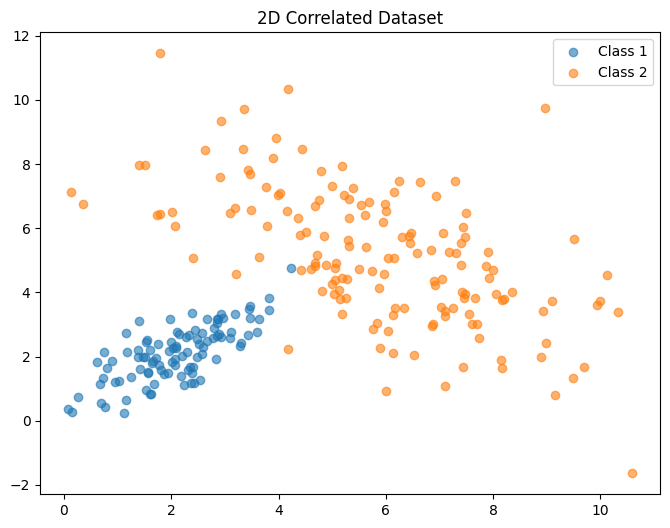

In [6]:
# TODO: generate the dataset

import numpy as np
import matplotlib.pyplot as plt

# 1. GENERATE SYNTHETIC DATA
np.random.seed(42)

# Class 1: Tight, positive correlation
n1 = 100
mu1 = np.array([2, 2])
sigma1 = np.array([[1.0, 0.8], [0.8, 1.0]])
X1 = np.random.multivariate_normal(mu1, sigma1, n1)

# Class 2: Wide, negative correlation
n2 = 150
mu2 = np.array([6, 5])
sigma2 = np.array([[4.0, -2.0], [-2.0, 4.0]])
X2 = np.random.multivariate_normal(mu2, sigma2, n2) # Unequal priors!

# Combine
X = np.vstack((X1, X2))
y = np.concatenate([np.zeros(n1), np.ones(n2)])

# 2. PLOT THE DATA
plt.figure(figsize=(8, 6))
plt.scatter(X1[:,0], X1[:,1], alpha=0.6, label='Class 1')
plt.scatter(X2[:,0], X2[:,1], alpha=0.6, label='Class 2')
plt.title("2D Correlated Dataset")
plt.legend()
plt.show()

## Parameter estimates

Now, estimate parameters from data; you can use the sample statistics from `numpy` for example:

In [7]:
# 2. Parameter Estimation
mu1_hat = X1.mean(axis=0)
mu2_hat = X2.mean(axis=0)

sigma1_hat = np.cov(X1, rowvar=False)
sigma2_hat = np.cov(X2, rowvar=False)

pi1_hat = len(X1) / len(X)
pi2_hat = len(X2) / len(X)

sigma_pooled = (
    (len(X1) - 1) * sigma1_hat + (len(X2) - 1) * sigma2_hat
) / (len(X1) + len(X2) - 2)

print("mu1_hat =", mu1_hat)
print("mu2_hat =", mu2_hat)
print("sigma1_hat =\n", sigma1_hat)
print("sigma2_hat =\n", sigma2_hat)
print("sigma_pooled =\n", sigma_pooled)
print(f"pi1_hat = {pi1_hat:.2f}, pi2_hat = {pi2_hat:.2f}")


mu1_hat = [2.09887507 2.12039268]
mu2_hat = [5.85484399 5.13672255]
sigma1_hat =
 [[0.77630465 0.56017324]
 [0.56017324 0.7431292 ]]
sigma2_hat =
 [[ 4.36945711 -2.58553297]
 [-2.58553297  4.39072587]]
sigma_pooled =
 [[ 2.93509383 -1.32978735]
 [-1.32978735  2.93462881]]
pi1_hat = 0.40, pi2_hat = 0.60


## Define discriminant functions

Remember these are functions $g_i(x) = \log P(y=C_i | x)$. The formulas are:

The QDA "Scoring" Function:
$$g_k(x) = -\frac{1}{2} \ln |\Sigma_k| - \frac{1}{2} (x - \mu_k)^T \Sigma_k^{-1} (x - \mu_k) + \ln \pi_k$$

The LDA "Scoring" Function:
$$g_k(x) = x^T \Sigma_p^{-1} \mu_k - \frac{1}{2} \mu_k^T \Sigma_p^{-1} \mu_k + \ln \pi_k$$

In [8]:
def qda_score(x, mu, sigma, pi):
    x = np.atleast_2d(x)
    sigma_inv = np.linalg.inv(sigma)
    _, logdet = np.linalg.slogdet(sigma)
    centered = x - mu
    quad_term = np.einsum("...i,ij,...j->...", centered, sigma_inv, centered)
    return -0.5 * logdet - 0.5 * quad_term + np.log(pi)


def lda_score(x, mu, sigma, pi):
    x = np.atleast_2d(x)
    sigma_inv = np.linalg.inv(sigma)
    return x @ sigma_inv @ mu - 0.5 * mu.T @ sigma_inv @ mu + np.log(pi)


def qda_delta(x, pi1=pi1_hat, pi2=pi2_hat):
    return qda_score(x, mu2_hat, sigma2_hat, pi2) - qda_score(
        x, mu1_hat, sigma1_hat, pi1
    )


def lda_delta(x, pi1=pi1_hat, pi2=pi2_hat):
    return lda_score(x, mu2_hat, sigma_pooled, pi2) - lda_score(
        x, mu1_hat, sigma_pooled, pi1
    )


## Visualize QDA/LDA decision boundaries

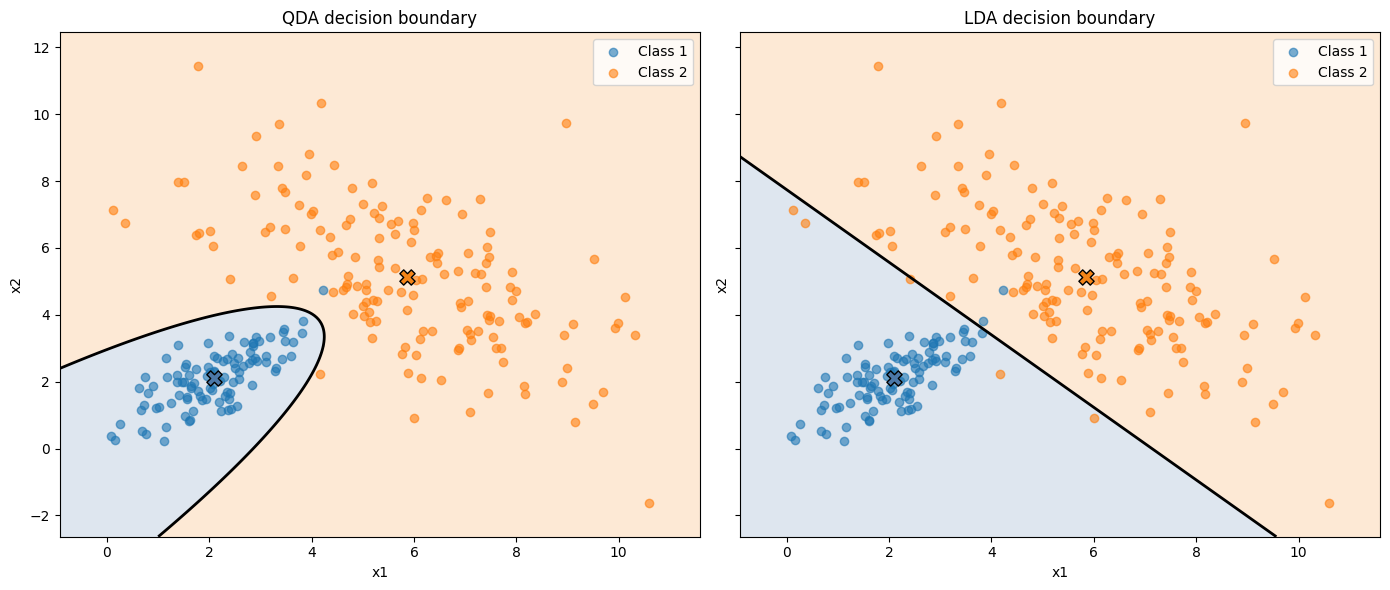

In [9]:
# Task 3: Visualization Grid
pad = 1.0
x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)
grid = np.c_[xx.ravel(), yy.ravel()]

# Evaluate deltas
qda_delta_grid = qda_delta(grid).reshape(xx.shape)
lda_delta_grid = lda_delta(grid).reshape(xx.shape)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
plots = [
    (axes[0], qda_delta_grid, "QDA decision boundary"),
    (axes[1], lda_delta_grid, "LDA decision boundary"),
]

for ax, delta, title in plots:
    ax.contourf(
        xx,
        yy,
        (delta > 0).astype(int),
        levels=[-0.5, 0.5, 1.5],
        colors=["#4c78a8", "#f58518"],
        alpha=0.18,
    )
    ax.contour(xx, yy, delta, levels=[0], colors="black", linewidths=2)
    ax.scatter(X1[:, 0], X1[:, 1], alpha=0.6, label="Class 1")
    ax.scatter(X2[:, 0], X2[:, 1], alpha=0.6, label="Class 2")
    ax.scatter(*mu1_hat, color="#4c78a8", marker="X", s=120, edgecolor="black")
    ax.scatter(*mu2_hat, color="#f58518", marker="X", s=120, edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend()

plt.tight_layout()
plt.show()


## Some questions you can experiment with

- How does the higher prior of Class 1 ($\pi_1 = 0.8$) affect the location of the boundary relative to the means?
- Why is the LDA boundary linear while the QDA boundary is curved?
- If $n_1$ and $n_2$ were equal, how would $\hat{\Sigma}_p$ change?
- What needs to be changed in order to draw the decision boundary for Gaussian NB ?

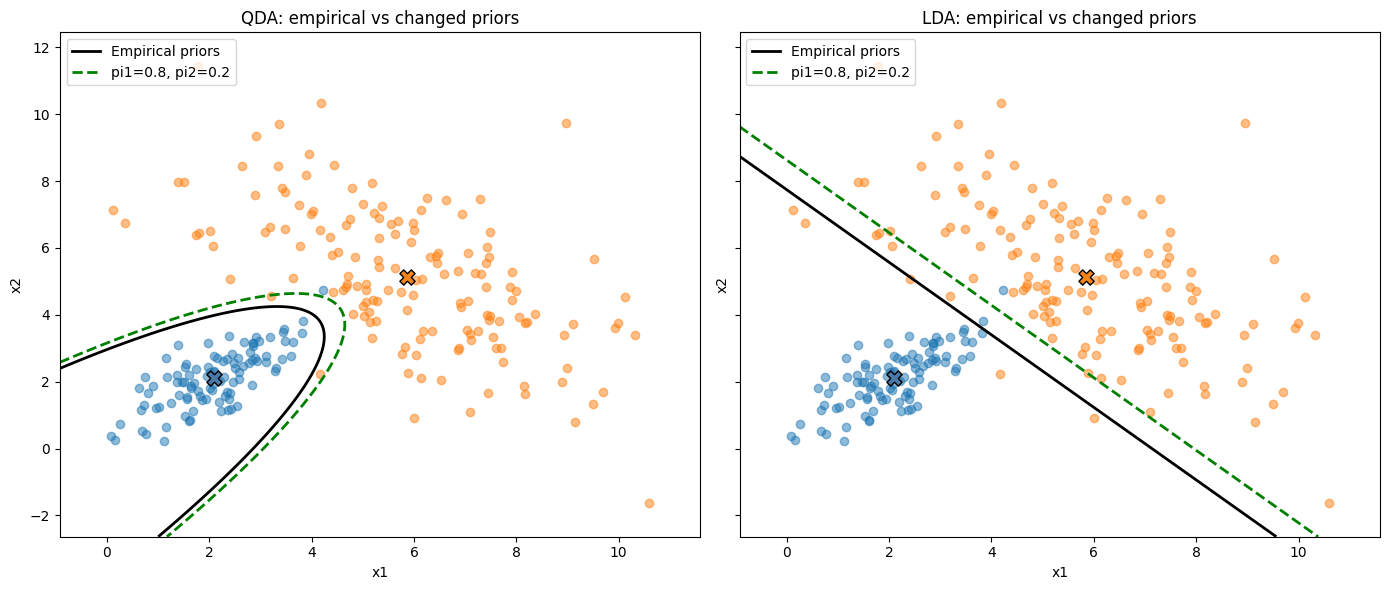

In [10]:
from matplotlib.lines import Line2D

# Task 3: Visualization Grid
pi1_demo, pi2_demo = 0.8, 0.2

# Evaluate deltas
qda_prior_shift = qda_delta(grid, pi1=pi1_demo, pi2=pi2_demo).reshape(xx.shape)
lda_prior_shift = lda_delta(grid, pi1=pi1_demo, pi2=pi2_demo).reshape(xx.shape)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
comparisons = [
    (axes[0], qda_delta_grid, qda_prior_shift, "QDA: empirical vs changed priors"),
    (axes[1], lda_delta_grid, lda_prior_shift, "LDA: empirical vs changed priors"),
]

legend_lines = [
    Line2D([0], [0], color="black", lw=2, linestyle="-", label="Empirical priors"),
    Line2D([0], [0], color="green", lw=2, linestyle="--", label="pi1=0.8, pi2=0.2"),
]

for ax, delta_empirical, delta_shifted, title in comparisons:
    ax.scatter(X1[:, 0], X1[:, 1], alpha=0.5, label="Class 1")
    ax.scatter(X2[:, 0], X2[:, 1], alpha=0.5, label="Class 2")
    ax.contour(xx, yy, delta_empirical, levels=[0], colors="black", linewidths=2)
    ax.contour(
        xx,
        yy,
        delta_shifted,
        levels=[0],
        colors="green",
        linewidths=2,
        linestyles="--",
    )
    ax.scatter(*mu1_hat, color="#4c78a8", marker="X", s=120, edgecolor="black")
    ax.scatter(*mu2_hat, color="#f58518", marker="X", s=120, edgecolor="black")
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend(handles=legend_lines, loc="upper left")

plt.tight_layout()
plt.show()


## Answers

- In this dataset the empirical priors are $\hat\pi_1 = 0.40$ and $\hat\pi_2 = 0.60$. If we increase $\pi_1$ to 0.8, the boundary moves toward Class 2, so a larger region is assigned to Class 1.
- LDA gives a linear boundary because both classes share the same covariance matrix, so the quadratic terms cancel out. QDA keeps one covariance matrix per class, so the quadratic terms remain and the boundary becomes curved.
- If $n_1$ and $n_2$ were equal, the pooled covariance would weight both class covariances equally. With unequal sample sizes, the larger class contributes more.
- For Gaussian Naive Bayes, replace each full covariance matrix by a diagonal covariance matrix that keeps only the per-feature variances. Then evaluate the same Gaussian discriminant with those diagonal matrices.
